In [74]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

plt.style.use("default")
plt.rcParams['figure.figsize'] = (10, 6)

# === Path to alerts CSV ===
ALERTS_CSV = Path(r"C:\Users\ishaa\OneDrive\Desktop\Features-main\Features-main\data\output\vehicle_alerts.csv")

# Load CSV
df_alerts = pd.read_csv(
    ALERTS_CSV,
    dtype=str,            # keep string columns intact
    keep_default_na=False
)

# Convert numeric fields
for col in ["duration_s", "n_points", "peak_composite", "mean_composite", "severity"]:
    if col in df_alerts.columns:
        df_alerts[col] = pd.to_numeric(df_alerts[col], errors="coerce")

print("Loaded:", ALERTS_CSV)
print(df_alerts.head())


Loaded: C:\Users\ishaa\OneDrive\Desktop\Features-main\Features-main\data\output\vehicle_alerts.csv
           alert_id vehicle_id   module                   start_ts  \
0  956ce7b4a44145d9     sim001  battery  2024-07-05T07:22:11+00:00   
1  a81c57582cfe4067     sim001  battery  2024-07-05T07:50:48+00:00   
2  f7de643eeb7a405c     sim001  battery  2024-07-05T07:52:55+00:00   
3  1957d31f1867429d     sim001  battery  2024-07-05T07:58:02+00:00   
4  c6aa30a0df6d4d5b     sim001  battery  2024-07-05T08:01:06+00:00   

                      end_ts  duration_s  n_points  peak_composite  \
0  2024-07-05T07:48:51+00:00        1600      1409        0.750221   
1  2024-07-05T07:50:48+00:00           0         1        0.485391   
2  2024-07-05T07:54:51+00:00         116        74        0.509287   
3  2024-07-05T07:58:02+00:00           0         1        0.641128   
4  2024-07-05T08:08:23+00:00         437       413        0.519413   

   mean_composite  severity severity_label  \
0        0.50

Using fixed thresholds on MEAN composite:
  ANOMALY  >= 0.483582
  WARNING  >= 0.608616
  CRITICAL >= 0.832554


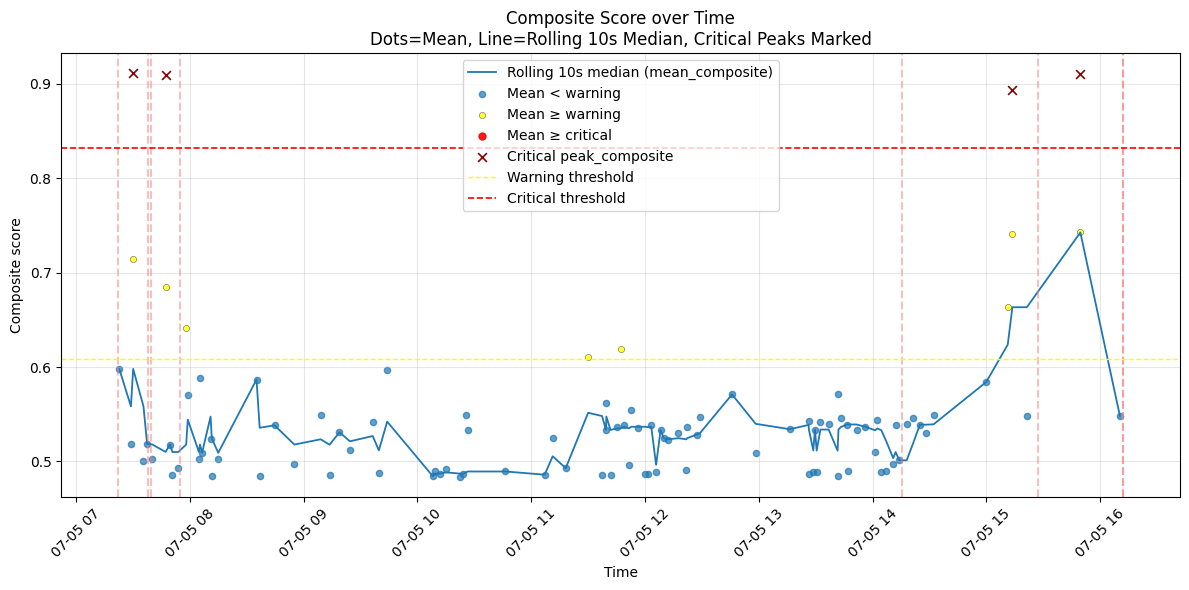

In [75]:
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("default")
plt.rcParams["figure.figsize"] = (12, 6)

# === Fixed thresholds (given) ===
ANOM_THRESH = 0.483582
WARN_THRESH = 0.608616
CRIT_THRESH = 0.832554

# --- Safety: required columns ---
required_cols = ["start_ts", "end_ts", "peak_composite", "mean_composite"]
missing = [c for c in required_cols if c not in df_alerts.columns]
if missing:
    raise KeyError(f"Missing required columns in df_alerts: {missing}")

# --- Work on a copy ---
df_plot = df_alerts.copy()

# Parse timestamps
df_plot["start_dt"] = pd.to_datetime(df_plot["start_ts"], errors="coerce")
df_plot["end_dt"]   = pd.to_datetime(df_plot["end_ts"],   errors="coerce")

# Numeric conversions
df_plot["peak_composite"] = pd.to_numeric(df_plot["peak_composite"], errors="coerce")
df_plot["mean_composite"] = pd.to_numeric(df_plot["mean_composite"], errors="coerce")

# Drop bad rows
df_plot = df_plot.dropna(subset=["start_dt", "end_dt", "peak_composite", "mean_composite"])
if df_plot.empty:
    raise ValueError("No valid rows to plot after cleaning timestamps and scores.")

# --- Midpoint time for each alert (x-axis position) ---
delta = df_plot["end_dt"] - df_plot["start_dt"]
mid_dt = df_plot["start_dt"] + delta / 2
mid_dt = mid_dt.where(delta.notna() & (delta >= pd.Timedelta(0)), df_plot["start_dt"])
df_plot["mid_dt"] = mid_dt

# === Rolling 10-second median of mean_composite ===
df_roll = df_plot.sort_values("mid_dt").set_index("mid_dt")
# Time-based rolling window of 10 seconds
df_roll["mean_rolling_med_10s"] = df_roll["mean_composite"].rolling("1000s").median()

# Masks based on *mean_composite* for coloring dots
scores_mean = df_plot["mean_composite"]
mask_crit   = scores_mean >= CRIT_THRESH
mask_warn   = (scores_mean >= WARN_THRESH) & (scores_mean < CRIT_THRESH)
mask_normal = scores_mean < WARN_THRESH

print("Using fixed thresholds on MEAN composite:")
print(f"  ANOMALY  >= {ANOM_THRESH}")
print(f"  WARNING  >= {WARN_THRESH}")
print(f"  CRITICAL >= {CRIT_THRESH}")

fig, ax = plt.subplots()

# 1) Line: rolling 10s median of mean_composite
ax.plot(
    df_roll.index,
    df_roll["mean_rolling_med_10s"],
    linestyle="-",
    linewidth=1.3,
    label="Rolling 10s median (mean_composite)",
)

# 2) Vertical lines for critical rows (start & end timestamps)
sev_col = "severity_label" if "severity_label" in df_plot.columns else None
if sev_col is not None:
    crit_rows = df_plot[df_plot[sev_col] == "critical"]
else:
    # fallback: classify critical via mean threshold
    crit_rows = df_plot[mask_crit]

for _, r in crit_rows.iterrows():
    if pd.isna(r["start_dt"]) or pd.isna(r["end_dt"]):
        continue
    ax.axvline(r["start_dt"], color="lightcoral", linestyle="--", alpha=0.5)
    ax.axvline(r["end_dt"],   color="lightcoral", linestyle="--", alpha=0.5)

# 3) Scatter dots of MEAN composite at midpoints (color by thresholds)
# normal (below warning)
ax.scatter(
    df_plot.loc[mask_normal, "mid_dt"],
    scores_mean[mask_normal],
    s=20,
    alpha=0.7,
    label="Mean < warning",
    color="tab:blue",
)

# warning band (>= warning & < critical) → yellow
ax.scatter(
    df_plot.loc[mask_warn, "mid_dt"],
    scores_mean[mask_warn],
    s=20,
    alpha=0.8,
    label="Mean ≥ warning",
    color="yellow",
    edgecolors="black",
    linewidths=0.3,
)

# critical band (>= critical) → red
ax.scatter(
    df_plot.loc[mask_crit, "mid_dt"],
    scores_mean[mask_crit],
    s=25,
    alpha=0.9,
    label="Mean ≥ critical",
    color="red",
)

# 4) For CRITICAL rows only: plot peak_composite as separate markers at mid_dt
ax.scatter(
    crit_rows["mid_dt"],
    crit_rows["peak_composite"],
    s=40,
    marker="x",
    linewidths=1.2,
    color="darkred",
    label="Critical peak_composite",
)

# 5) Horizontal threshold lines (warning & critical)
ax.axhline(
    WARN_THRESH,
    linestyle="--",
    linewidth=1.0,
    color="yellow",
    label="Warning threshold",
)
ax.axhline(
    CRIT_THRESH,
    linestyle="--",
    linewidth=1.2,
    color="red",
    label="Critical threshold",
)

# 6) X-axis range: [min(start/end) - 30min, max(start/end) + 30min]
global_min = min(df_plot["start_dt"].min(), df_plot["end_dt"].min())
global_max = max(df_plot["start_dt"].max(), df_plot["end_dt"].max())
offset = pd.Timedelta(minutes=30)
ax.set_xlim(global_min - offset, global_max + offset)

# Formatting
ax.set_title("Composite Score over Time\nDots=Mean, Line=Rolling 10s Median, Critical Peaks Marked")
ax.set_xlabel("Time")
ax.set_ylabel("Composite score")
ax.grid(alpha=0.3)
plt.xticks(rotation=45)

# Deduplicate legend entries
handles, labels = ax.get_legend_handles_labels()
unique = dict(zip(labels, handles))
ax.legend(unique.values(), unique.keys(), loc="best")

plt.tight_layout()
plt.show()


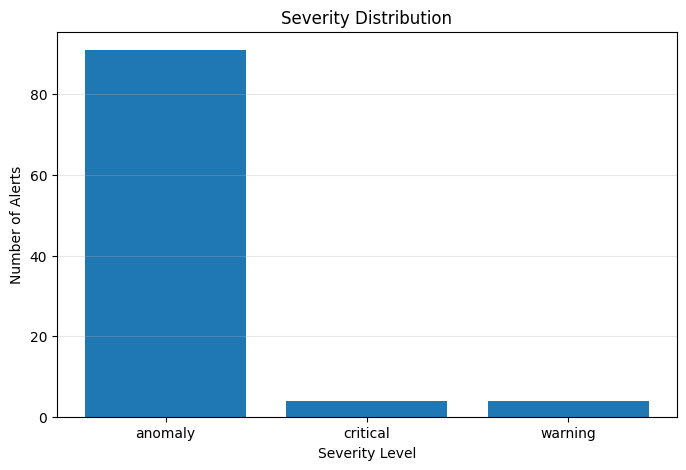

severity_label
anomaly     91
critical     4
warning      4
Name: count, dtype: int64


In [76]:
severity_counts = df_alerts["severity_label"].value_counts().sort_index()

plt.figure(figsize=(8, 5))
plt.bar(severity_counts.index, severity_counts.values)
plt.title("Severity Distribution")
plt.xlabel("Severity Level")
plt.ylabel("Number of Alerts")
plt.grid(axis='y', alpha=0.3)
plt.show()

print(severity_counts)


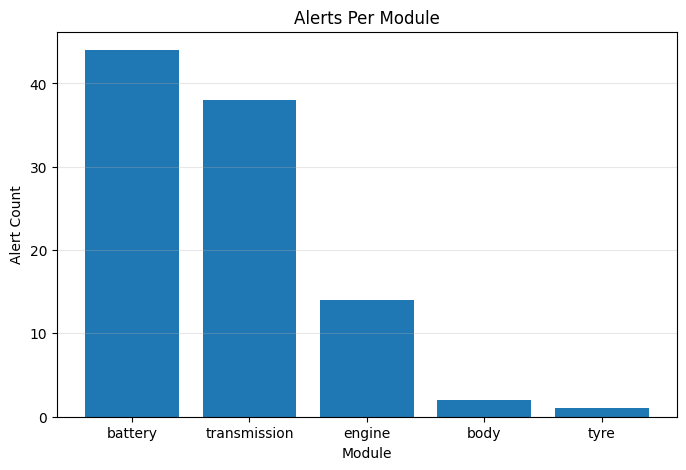

module
battery         44
transmission    38
engine          14
body             2
tyre             1
Name: count, dtype: int64


In [77]:
# Cell 3 - alerts per module

module_counts = df_alerts["module"].value_counts()

plt.figure(figsize=(8, 5))
plt.bar(module_counts.index, module_counts.values)
plt.title("Alerts Per Module")
plt.xlabel("Module")
plt.ylabel("Alert Count")
plt.grid(axis='y', alpha=0.3)
plt.show()

print(module_counts)


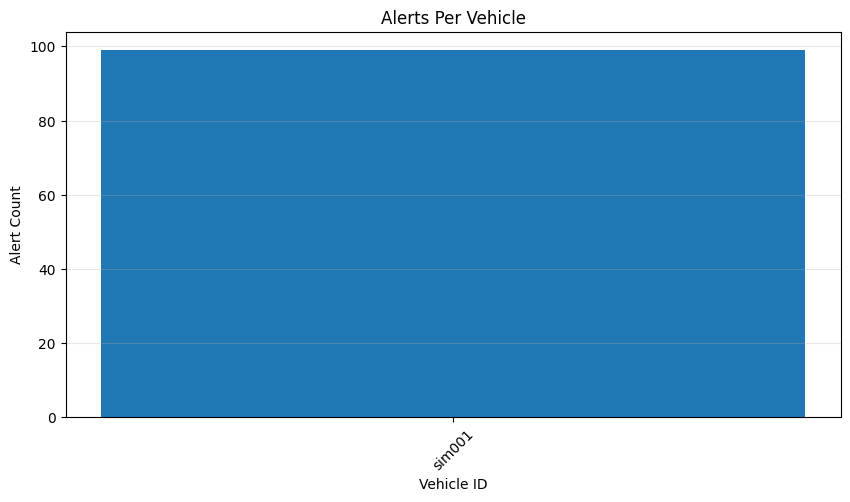

vehicle_id
sim001    99
Name: count, dtype: int64


In [78]:
# Cell 4 - alerts per vehicle

vehicle_counts = df_alerts["vehicle_id"].value_counts()

plt.figure(figsize=(10, 5))
plt.bar(vehicle_counts.index, vehicle_counts.values)
plt.title("Alerts Per Vehicle")
plt.xlabel("Vehicle ID")
plt.ylabel("Alert Count")
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.show()

print(vehicle_counts)


In [79]:
# Cell 5 - derive datetime, hour-of-day, and date columns

import pandas as pd

# We’ll use start_ts as the primary time for the alert
if "start_ts" not in df_alerts.columns:
    raise KeyError("Column 'start_ts' not found in df_alerts. Check alerts CSV schema.")

# Parse start_ts to datetime
df_alerts["start_dt"] = pd.to_datetime(df_alerts["start_ts"], errors="coerce")

# Drop rows where timestamp parsing failed (optional but cleaner for time plots)
df_time = df_alerts.dropna(subset=["start_dt"]).copy()

# Hour of day (0–23) and date (date-only)
df_time["hour_of_day"] = df_time["start_dt"].dt.hour
df_time["date_only"] = df_time["start_dt"].dt.date

print("Rows with valid timestamps:", len(df_time), "out of", len(df_alerts))
print(df_time[["start_ts", "start_dt", "hour_of_day", "date_only"]].head())


Rows with valid timestamps: 99 out of 99
                    start_ts                  start_dt  hour_of_day  \
0  2024-07-05T07:22:11+00:00 2024-07-05 07:22:11+00:00            7   
1  2024-07-05T07:50:48+00:00 2024-07-05 07:50:48+00:00            7   
2  2024-07-05T07:52:55+00:00 2024-07-05 07:52:55+00:00            7   
3  2024-07-05T07:58:02+00:00 2024-07-05 07:58:02+00:00            7   
4  2024-07-05T08:01:06+00:00 2024-07-05 08:01:06+00:00            8   

    date_only  
0  2024-07-05  
1  2024-07-05  
2  2024-07-05  
3  2024-07-05  
4  2024-07-05  


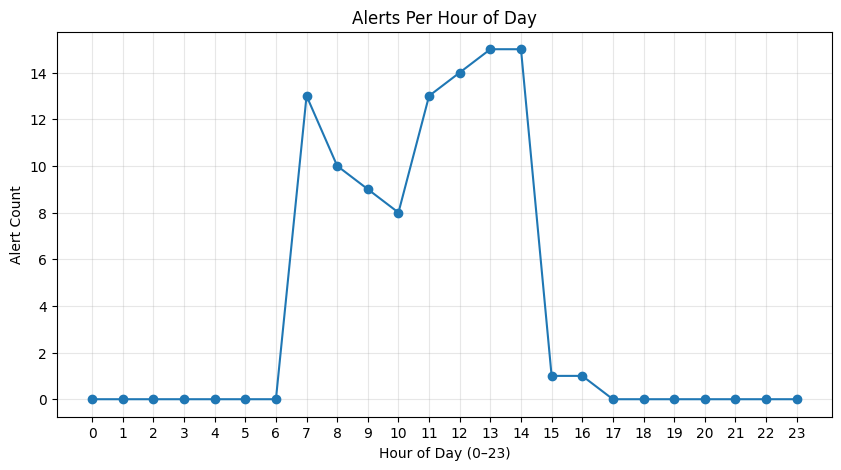

hour_of_day
0      0
1      0
2      0
3      0
4      0
5      0
6      0
7     13
8     10
9      9
10     8
11    13
12    14
13    15
14    15
15     1
16     1
17     0
18     0
19     0
20     0
21     0
22     0
23     0
Name: alert_id, dtype: int64


In [80]:
# Cell 6 - alerts per hour of day

import matplotlib.pyplot as plt

alerts_per_hour = df_time.groupby("hour_of_day")["alert_id"].count().reindex(range(24), fill_value=0)

plt.figure(figsize=(10, 5))
plt.plot(alerts_per_hour.index, alerts_per_hour.values, marker="o")
plt.title("Alerts Per Hour of Day")
plt.xlabel("Hour of Day (0–23)")
plt.ylabel("Alert Count")
plt.grid(True, axis="both", alpha=0.3)
plt.xticks(range(0, 24))
plt.show()

print(alerts_per_hour)


C:\Users\ishaa\AppData\Local\Temp\ipykernel_21472\2668929085.py:4: FutureWarning:

'H' is deprecated and will be removed in a future version, please use 'h' instead.



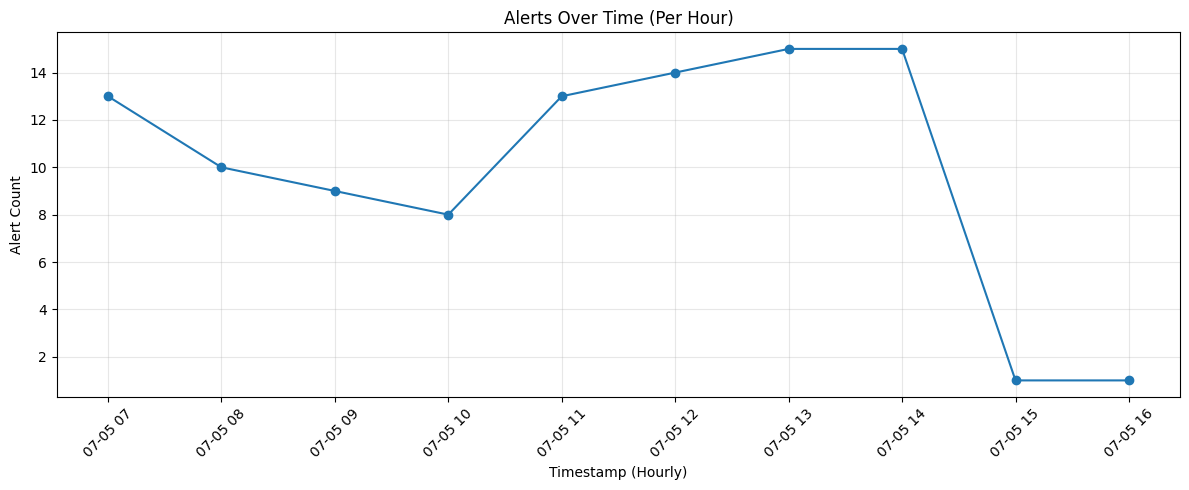

hour_bucket
2024-07-05 07:00:00+00:00    13
2024-07-05 08:00:00+00:00    10
2024-07-05 09:00:00+00:00     9
2024-07-05 10:00:00+00:00     8
2024-07-05 11:00:00+00:00    13
2024-07-05 12:00:00+00:00    14
2024-07-05 13:00:00+00:00    15
2024-07-05 14:00:00+00:00    15
2024-07-05 15:00:00+00:00     1
2024-07-05 16:00:00+00:00     1
Name: alert_id, dtype: int64


In [81]:
# Cell 7 - alerts over time (per hour)

# Construct an hourly timestamp bucket
df_time["hour_bucket"] = df_time["start_dt"].dt.floor("H")

alerts_per_hour_ts = (
    df_time
    .groupby("hour_bucket")["alert_id"]
    .count()
    .sort_index()
)

plt.figure(figsize=(12, 5))
plt.plot(alerts_per_hour_ts.index, alerts_per_hour_ts.values, marker="o")
plt.title("Alerts Over Time (Per Hour)")
plt.xlabel("Timestamp (Hourly)")
plt.ylabel("Alert Count")
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(alerts_per_hour_ts)


Duration stats (s):
count       99.000000
mean      1128.272727
std       3549.300531
min          0.000000
25%         23.000000
50%        116.000000
75%        467.500000
max      31797.000000
Name: duration_s, dtype: float64


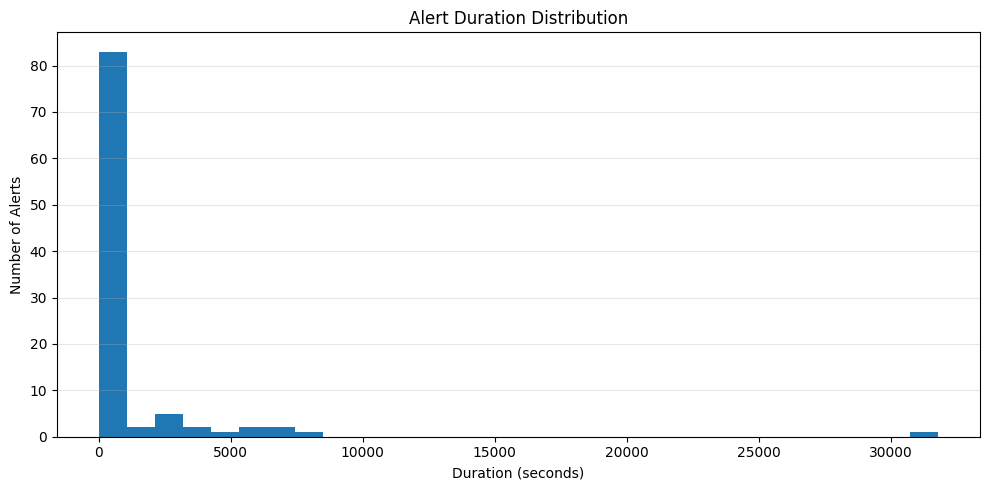

In [82]:
# Cell 9 - alert duration distribution (seconds)

import numpy as np
import matplotlib.pyplot as plt

durations = df_alerts["duration_s"].dropna()

print("Duration stats (s):")
print(durations.describe())

plt.figure(figsize=(10, 5))
plt.hist(durations, bins=30)
plt.title("Alert Duration Distribution")
plt.xlabel("Duration (seconds)")
plt.ylabel("Number of Alerts")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


n_points stats:
count       99.000000
mean       803.010101
std       3357.911749
min          1.000000
25%          7.000000
50%         48.000000
75%        232.000000
max      31797.000000
Name: n_points, dtype: float64


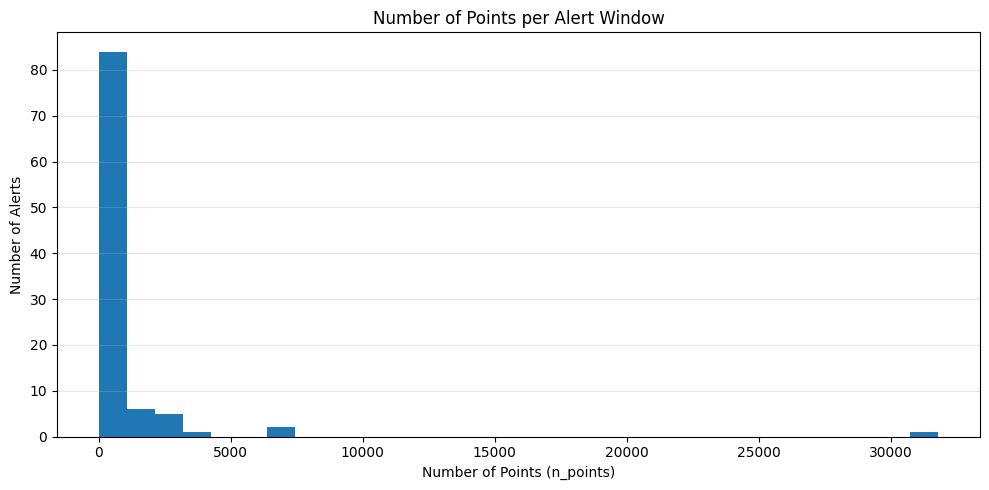

In [83]:
# Cell 10 - number of points per alert window

n_points = df_alerts["n_points"].dropna()

print("n_points stats:")
print(n_points.describe())

plt.figure(figsize=(10, 5))
plt.hist(n_points, bins=30)
plt.title("Number of Points per Alert Window")
plt.xlabel("Number of Points (n_points)")
plt.ylabel("Number of Alerts")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


Valid rows for scatter: 99 out of 99


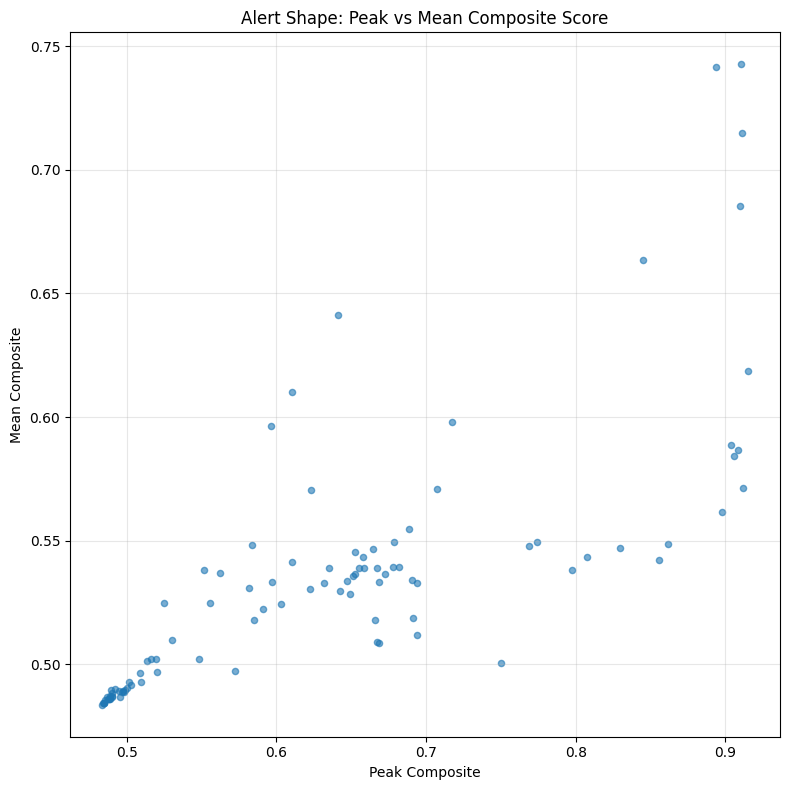

In [84]:
# Cell 11 - peak vs mean composite scatter

peak = df_alerts["peak_composite"]
mean = df_alerts["mean_composite"]

valid = (~peak.isna()) & (~mean.isna())
peak_valid = peak[valid]
mean_valid = mean[valid]

print("Valid rows for scatter:", valid.sum(), "out of", len(df_alerts))

plt.figure(figsize=(8, 8))
plt.scatter(peak_valid, mean_valid, s=20, alpha=0.6)
plt.title("Alert Shape: Peak vs Mean Composite Score")
plt.xlabel("Peak Composite")
plt.ylabel("Mean Composite")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [85]:
# Cell 13 - decode top_features_b64 into a long-form features dataframe

import base64
import json
import numpy as np
import pandas as pd

def decode_top_features_cell(cell_value: str):
    """
    Decode a top_features_b64 cell into a list of {feature, contribution} dicts.
    Handles:
    - empty / NaN
    - multiple base64 blobs separated by '|'
    - JSON list of dicts, or single dict
    """
    if cell_value is None or (isinstance(cell_value, float) and np.isnan(cell_value)):
        return []

    s = str(cell_value).strip()
    if not s:
        return []

    parts = s.split("|")
    results = []

    for part in parts:
        part = part.strip()
        if not part:
            continue
        try:
            decoded = base64.b64decode(part, validate=False)
            obj = json.loads(decoded.decode("utf-8"))
        except Exception:
            continue

        if isinstance(obj, list):
            for item in obj:
                if isinstance(item, dict) and "feature" in item and "contribution" in item:
                    results.append(
                        {
                            "feature": str(item["feature"]),
                            "contribution": float(item["contribution"]),
                        }
                    )
        elif isinstance(obj, dict) and "feature" in obj and "contribution" in obj:
            results.append(
                {
                    "feature": str(obj["feature"]),
                    "contribution": float(obj["contribution"]),
                }
            )

    return results


# Build long-form dataframe: one row per (alert_id, feature)
feature_rows = []

for idx, row in df_alerts.iterrows():
    alert_id = row.get("alert_id")
    module = row.get("module")
    severity_label = row.get("severity_label")
    start_ts = row.get("start_ts")
    top_feats_raw = row.get("top_features_b64", "")

    feats = decode_top_features_cell(top_feats_raw)
    for rank, f in enumerate(feats):
        feature_rows.append(
            {
                "alert_id": alert_id,
                "module": module,
                "severity_label": severity_label,
                "start_ts": start_ts,
                "feature": f["feature"],
                "contribution": f["contribution"],
                "rank": rank,
            }
        )

df_feats = pd.DataFrame(feature_rows)

print("Decoded feature contributions:")
print("Rows:", len(df_feats))
print(df_feats.head())


Decoded feature contributions:
Rows: 297
           alert_id   module severity_label                   start_ts  \
0  956ce7b4a44145d9  battery        anomaly  2024-07-05T07:22:11+00:00   
1  956ce7b4a44145d9  battery        anomaly  2024-07-05T07:22:11+00:00   
2  956ce7b4a44145d9  battery        anomaly  2024-07-05T07:22:11+00:00   
3  a81c57582cfe4067  battery        anomaly  2024-07-05T07:50:48+00:00   
4  a81c57582cfe4067  battery        anomaly  2024-07-05T07:50:48+00:00   

                                             feature  contribution  rank  
0                            hv_battery_pack_current      0.814362     0  
1  energy_consumption_per_km_wh_per_km_per_inr_pe...      0.618046     1  
2                            battery_voltage_ecu_7ee      0.500382     2  
3                            battery_voltage_ecu_7ee      0.061575     0  
4          fuel_consumption_km_per_l_or_l_per_100_km      0.050318     1  


Chosen alert_id: e1e8add558534e5a, severity: critical


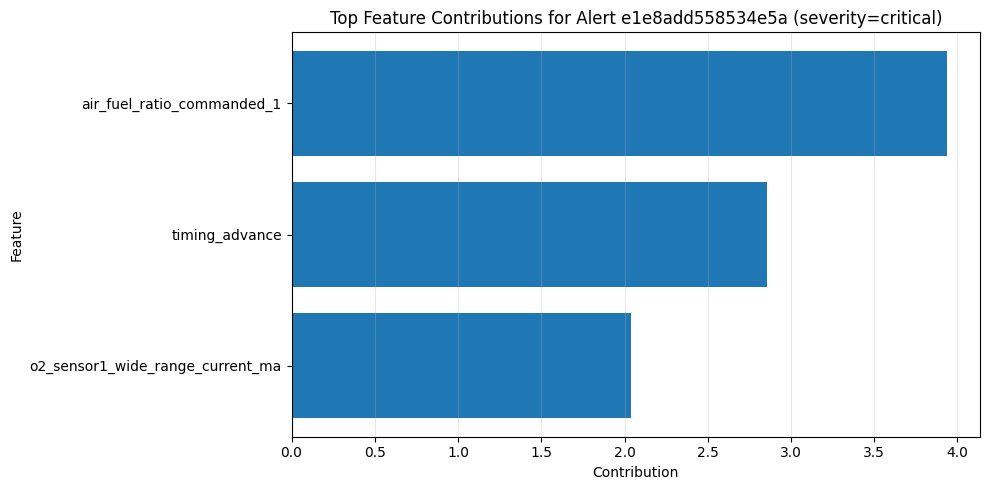

                              feature  contribution
138        air_fuel_ratio_commanded_1      3.938247
139                    timing_advance      2.856796
140  o2_sensor1_wide_range_current_ma      2.038383


In [86]:
# Cell 14 - per-alert feature contribution bar plot

import matplotlib.pyplot as plt

if df_feats.empty:
    print("No decoded features found in df_feats; cannot plot per-alert contributions.")
else:
    # Choose an alert to visualize: critical > anomaly > warning
    severity_priority = ["critical","anomaly", "warning"]
    chosen_alert_id = None

    for sev in severity_priority:
        subset = df_alerts[df_alerts["severity_label"] == sev]
        if not subset.empty:
            chosen_alert_id = subset.sort_values("peak_composite", ascending=False).iloc[0]["alert_id"]
            chosen_severity = sev
            break

    if chosen_alert_id is None:
        # fallback: first alert
        chosen_row = df_alerts.iloc[0]
        chosen_alert_id = chosen_row["alert_id"]
        chosen_severity = chosen_row["severity_label"]
        print("No critical/anomaly/warning separation found, using first alert.")

    print(f"Chosen alert_id: {chosen_alert_id}, severity: {chosen_severity}")

    df_alert_feats = df_feats[df_feats["alert_id"] == chosen_alert_id].copy()

    if df_alert_feats.empty:
        print("No decoded features for chosen alert; pick another alert or check encoding.")
    else:
        # Take top K features by absolute contribution
        K = 10
        df_alert_feats["abs_contribution"] = df_alert_feats["contribution"].abs()
        df_top = df_alert_feats.sort_values("abs_contribution", ascending=False).head(K)

        plt.figure(figsize=(10, 5))
        plt.barh(df_top["feature"], df_top["contribution"])
        plt.title(f"Top Feature Contributions for Alert {chosen_alert_id} (severity={chosen_severity})")
        plt.xlabel("Contribution")
        plt.ylabel("Feature")
        plt.gca().invert_yaxis()  # highest at top
        plt.grid(axis="x", alpha=0.3)
        plt.tight_layout()
        plt.show()

        print(df_top[["feature", "contribution"]])


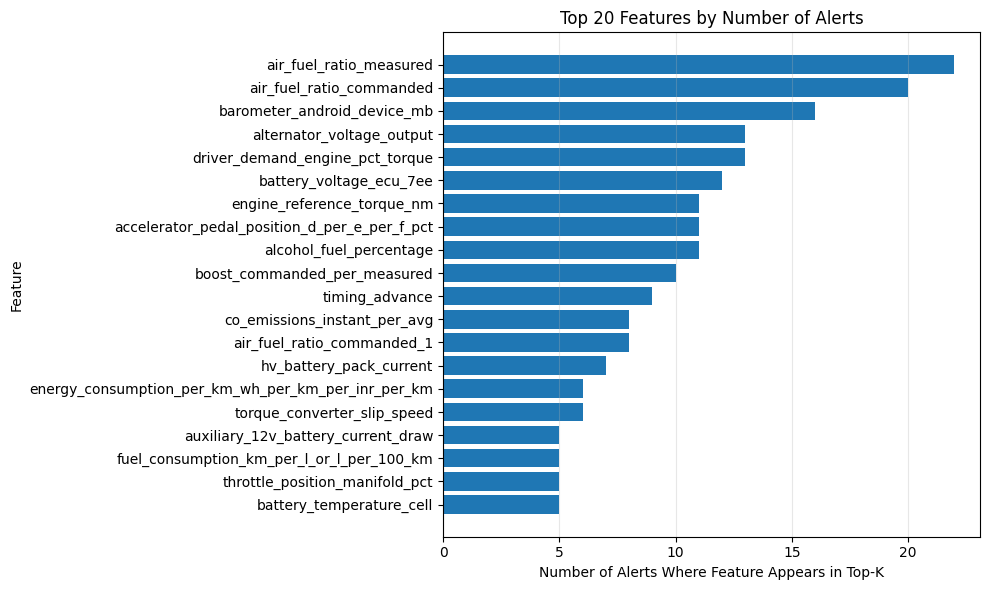

feature
air_fuel_ratio_measured                               22
air_fuel_ratio_commanded                              20
barometer_android_device_mb                           16
alternator_voltage_output                             13
driver_demand_engine_pct_torque                       13
battery_voltage_ecu_7ee                               12
engine_reference_torque_nm                            11
accelerator_pedal_position_d_per_e_per_f_pct          11
alcohol_fuel_percentage                               11
boost_commanded_per_measured                          10
timing_advance                                         9
co_emissions_instant_per_avg                           8
air_fuel_ratio_commanded_1                             8
hv_battery_pack_current                                7
energy_consumption_per_km_wh_per_km_per_inr_per_km     6
torque_converter_slip_speed                            6
auxiliary_12v_battery_current_draw                     5
fuel_consumption_km_per

In [87]:
# Cell 15 - fleet-level feature contribution frequency

if df_feats.empty:
    print("df_feats is empty; cannot compute fleet-level feature stats.")
else:
    # unique alerts per feature
    feat_alert_counts = (
        df_feats[["feature", "alert_id"]]
        .dropna()
        .drop_duplicates()
        .groupby("feature")["alert_id"]
        .nunique()
        .sort_values(ascending=False)
    )

    top_N = 20
    feat_top = feat_alert_counts.head(top_N)

    plt.figure(figsize=(10, 6))
    plt.barh(feat_top.index, feat_top.values)
    plt.title(f"Top {len(feat_top)} Features by Number of Alerts")
    plt.xlabel("Number of Alerts Where Feature Appears in Top-K")
    plt.ylabel("Feature")
    plt.gca().invert_yaxis()
    plt.grid(axis="x", alpha=0.3)
    plt.tight_layout()
    plt.show()

    print(feat_top)


severity_label  warning  anomaly  critical
module                                    
battery               2       41         1
body                  2        0         0
engine                0       11         3
transmission          0       38         0
tyre                  0        1         0


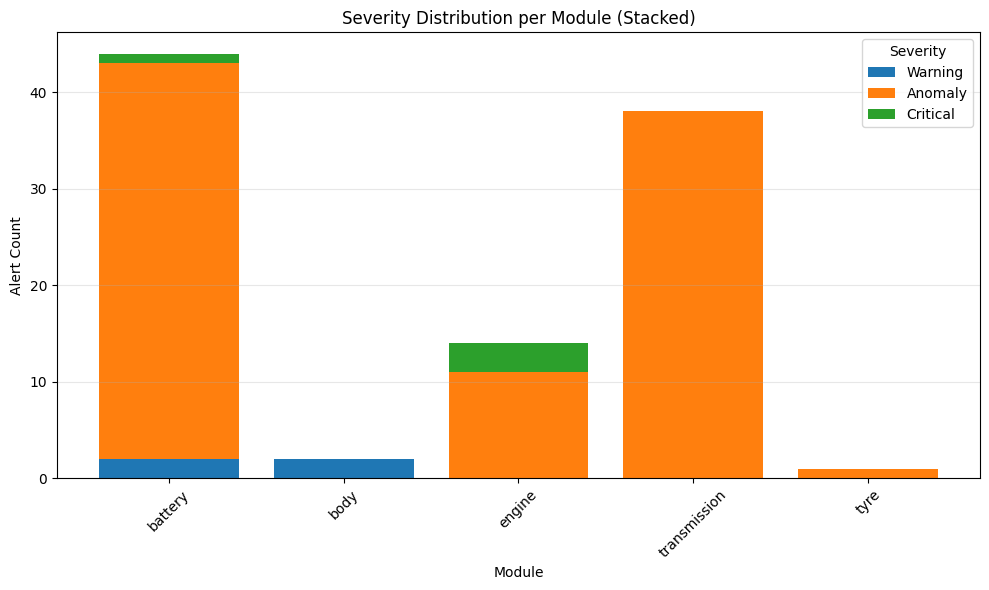

In [88]:
# Cell 21 - Stacked bar chart: severity distribution per module

severity_levels = ["warning", "anomaly", "critical"]

df_pivot = (
    df_alerts.groupby(["module", "severity_label"])["alert_id"]
    .count()
    .unstack(fill_value=0)
    .reindex(columns=severity_levels, fill_value=0)
)

print(df_pivot)

# Plot
plt.figure(figsize=(10, 6))

bottom = np.zeros(len(df_pivot))

for sev in severity_levels:
    plt.bar(df_pivot.index, df_pivot[sev], bottom=bottom, label=sev.capitalize())
    bottom += df_pivot[sev].values

plt.title("Severity Distribution per Module (Stacked)")
plt.xlabel("Module")
plt.ylabel("Alert Count")
plt.xticks(rotation=45)
plt.legend(title="Severity")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


Recomputed thresholds:
ANOMALY: 0.622146504679047
CRITICAL: 0.9115191058647005


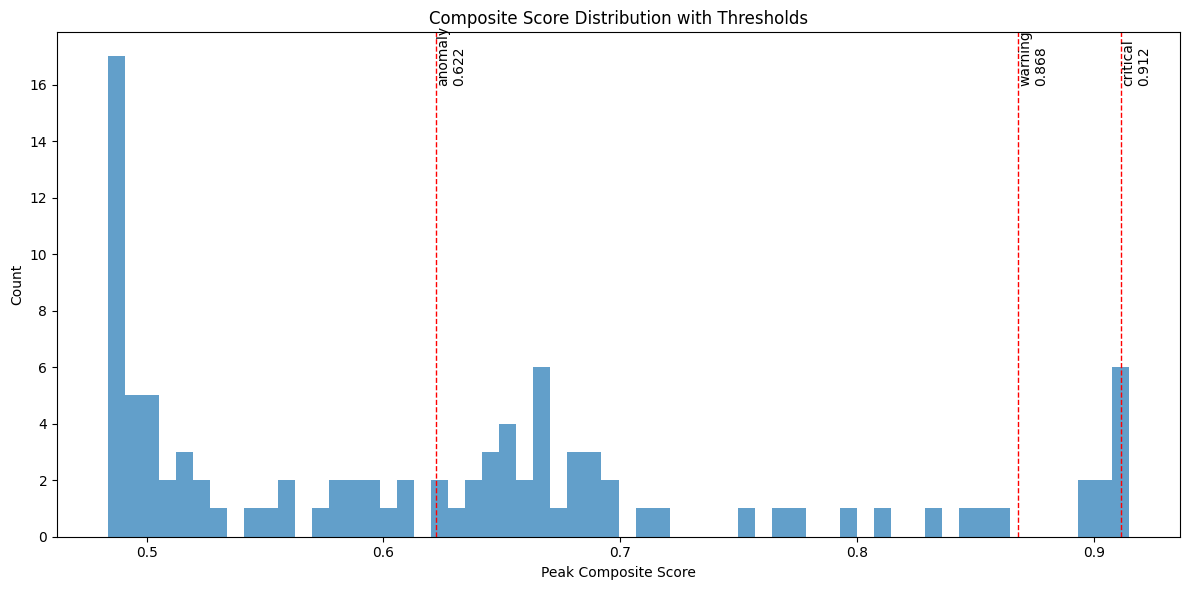

Threshold values:
anomaly   : 0.622147
critical  : 0.911519


In [89]:
# Cell 24 - Density of alerts near thresholds

import matplotlib.pyplot as plt
import numpy as np

# We assume q_warn, q_anom, q_crit from your alert generation notebook are available.

# Cell X - recompute thresholds from alerts.csv

scores = df_alerts["peak_composite"].dropna()

# Use the same percentiles used during alert generation
PCT_WARN = 0.90
PCT_ANOM = 0.50
PCT_CRIT = 0.99

q_warn = scores.quantile(PCT_WARN)
q_anom = scores.quantile(PCT_ANOM)
q_crit = scores.quantile(PCT_CRIT)

print("Recomputed thresholds:")
print("WARNING:", q_warn)
print("ANOMALY:", q_anom)
print("CRITICAL:", q_crit)

thresholds = {
    "warning": q_warn,
    "anomaly": q_anom,
    "critical": q_crit,
}

scores = df_alerts["peak_composite"].dropna()

plt.figure(figsize=(12, 6))
plt.hist(scores, bins=60, alpha=0.7)
plt.title("Composite Score Distribution with Thresholds")
plt.xlabel("Peak Composite Score")
plt.ylabel("Count")

# Draw threshold lines
for name, val in thresholds.items():
    plt.axvline(val, color="red", linestyle="--", linewidth=1)
    plt.text(val, plt.ylim()[1]*0.9, f"{name}\n{val:.3f}", rotation=90)

plt.tight_layout()
plt.show()

print("Threshold values:")
for name, val in thresholds.items():
    print(f"{name:10s}: {val:.6f}")


C:\Users\ishaa\AppData\Local\Temp\ipykernel_21472\3866183353.py:19: FutureWarning:

'H' is deprecated and will be removed in a future version, please use 'h' instead.



Hourly average severity:
                hour_bucket  severity_num
0 2024-07-05 07:00:00+00:00      2.000000
1 2024-07-05 08:00:00+00:00      2.000000
2 2024-07-05 09:00:00+00:00      2.000000
3 2024-07-05 10:00:00+00:00      2.000000
4 2024-07-05 11:00:00+00:00      1.923077


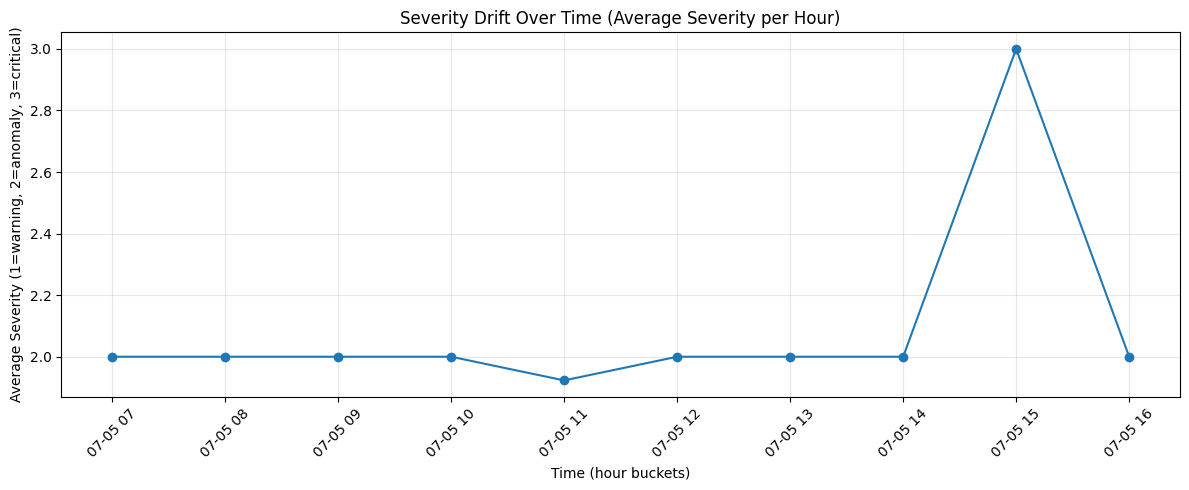

In [90]:
# Cell 25 - Severity drift over time (average severity per hour)

import matplotlib.pyplot as plt
import pandas as pd

# Map severity labels to numeric scores
severity_map = {"warning": 1, "anomaly": 2, "critical": 3}

df_sev_hour = df_alerts.copy()
df_sev_hour["severity_num"] = df_sev_hour["severity_label"].map(severity_map)

# Ensure datetime is available
if "start_dt" not in df_sev_hour.columns:
    df_sev_hour["start_dt"] = pd.to_datetime(df_sev_hour["start_ts"], errors="coerce")

df_sev_hour = df_sev_hour.dropna(subset=["start_dt"])

# Hourly bucket
df_sev_hour["hour_bucket"] = df_sev_hour["start_dt"].dt.floor("H")

# Average severity per hour
hourly_sev = (
    df_sev_hour
    .groupby("hour_bucket")["severity_num"]
    .mean()
    .reset_index()
    .sort_values("hour_bucket")
)

print("Hourly average severity:")
print(hourly_sev.head())

plt.figure(figsize=(12, 5))
plt.plot(hourly_sev["hour_bucket"], hourly_sev["severity_num"], marker="o")
plt.title("Severity Drift Over Time (Average Severity per Hour)")
plt.xlabel("Time (hour buckets)")
plt.ylabel("Average Severity (1=warning, 2=anomaly, 3=critical)")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
